# Data Preparation

In [87]:
import sklearn as skl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing

from sklearn.model_selection import cross_val_score

In [88]:
dt = pd.read_csv("datasets/training_data.csv", encoding='utf-8', encoding_errors='ignore')

In [89]:
data = dt.copy()

In [90]:
data.drop(columns=['city_name', 'AVERAGE_PRECIPITATION'], axis=1,  inplace=True)
data.head()

,record_date,AVERAGE_SPEED_DIFF,AVERAGE_FREE_FLOW_SPEED,AVERAGE_TIME_DIFF,AVERAGE_FREE_FLOW_TIME,LUMINOSITY,AVERAGE_TEMPERATURE,AVERAGE_ATMOSP_PRESSURE,AVERAGE_HUMIDITY,AVERAGE_WIND_SPEED,AVERAGE_CLOUDINESS,AVERAGE_RAIN
0,2019-08-29 07:00:00,Medium,41.5,11.5,71.4,LIGHT,15.0,1019.0,100.0,3.0,NaN,NaN
1,2018-08-10 14:00:00,High,41.7,48.3,87.4,LIGHT,21.0,1021.0,53.0,5.0,cu claro,NaN
2,2019-09-01 16:00:00,High,38.6,38.4,85.2,LIGHT,26.0,1014.0,61.0,4.0,NaN,NaN
3,2019-02-26 11:00:00,High,37.4,61.0,94.1,LIGHT,18.0,1025.0,48.0,4.0,cu claro,NaN
4,2019-06-06 12:00:00,Medium,41.6,50.4,77.0,LIGHT,15.0,1008.0,82.0,10.0,NaN,NaN


In [91]:
data['AVERAGE_SPEED_DIFF'] = pd.factorize(data['AVERAGE_SPEED_DIFF'])[0] + 1
data['LUMINOSITY'] = pd.factorize(data['LUMINOSITY'])[0] + 1
data.tail()

,record_date,AVERAGE_SPEED_DIFF,AVERAGE_FREE_FLOW_SPEED,AVERAGE_TIME_DIFF,AVERAGE_FREE_FLOW_TIME,LUMINOSITY,AVERAGE_TEMPERATURE,AVERAGE_ATMOSP_PRESSURE,AVERAGE_HUMIDITY,AVERAGE_WIND_SPEED,AVERAGE_CLOUDINESS,AVERAGE_RAIN
6807,2019-02-23 09:00:00,3,41.2,3.7,86.9,1,9.0,1030.0,71.0,4.0,cu claro,NaN
6808,2019-06-08 18:00:00,1,38.9,51.9,76.9,1,17.0,1020.0,63.0,6.0,NaN,NaN
6809,2018-10-02 04:00:00,0,39.6,0.0,89.1,3,15.0,1020.0,39.0,4.0,cu claro,NaN
6810,2019-01-30 01:00:00,0,41.6,0.0,85.5,3,8.0,1018.0,81.0,1.0,algumas nuvens,NaN
6811,2019-06-15 21:00:00,1,41.7,32.9,78.1,3,15.0,1021.0,72.0,4.0,NaN,NaN


In [92]:
data['record_date'] = pd.to_datetime(data['record_date'], format='%Y-%m-%d %H:%M:%S', errors = 'coerce')
assert data['record_date'].isnull().sum() == 0, "There are invalid date entries in 'record_date' column"
data['record_date'].head()

0   2019-08-29 07:00:00
1   2018-08-10 14:00:00
2   2019-09-01 16:00:00
3   2019-02-26 11:00:00
4   2019-06-06 12:00:00
Name: record_date, dtype: datetime64[ns]

In [93]:
data['YEAR'] = data['record_date'].dt.year
data['MONTH'] = data['record_date'].dt.month
data['DAY'] = data['record_date'].dt.day
data['HOUR'] = data['record_date'].dt.hour
data['MINUTE'] = data['record_date'].dt.minute
data['SECOND'] = data['record_date'].dt.second

data.nunique()

record_date                6812
AVERAGE_SPEED_DIFF            5
AVERAGE_FREE_FLOW_SPEED     225
AVERAGE_TIME_DIFF          1151
AVERAGE_FREE_FLOW_TIME      442
LUMINOSITY                    3
AVERAGE_TEMPERATURE          38
AVERAGE_ATMOSP_PRESSURE      43
AVERAGE_HUMIDITY             77
AVERAGE_WIND_SPEED           15
AVERAGE_CLOUDINESS            9
AVERAGE_RAIN                 13
YEAR                          2
MONTH                        12
DAY                          31
HOUR                         24
MINUTE                        1
SECOND                        1
dtype: int64

In [94]:
data.drop('MINUTE', axis=1,  inplace=True)
data.drop('SECOND', axis=1,  inplace=True)
data.drop('record_date', axis=1,  inplace=True)
data.head()

,AVERAGE_SPEED_DIFF,AVERAGE_FREE_FLOW_SPEED,AVERAGE_TIME_DIFF,AVERAGE_FREE_FLOW_TIME,LUMINOSITY,AVERAGE_TEMPERATURE,AVERAGE_ATMOSP_PRESSURE,AVERAGE_HUMIDITY,AVERAGE_WIND_SPEED,AVERAGE_CLOUDINESS,AVERAGE_RAIN,YEAR,MONTH,DAY,HOUR
0,1,41.5,11.5,71.4,1,15.0,1019.0,100.0,3.0,NaN,NaN,2019,8,29,7
1,2,41.7,48.3,87.4,1,21.0,1021.0,53.0,5.0,cu claro,NaN,2018,8,10,14
2,2,38.6,38.4,85.2,1,26.0,1014.0,61.0,4.0,NaN,NaN,2019,9,1,16
3,2,37.4,61.0,94.1,1,18.0,1025.0,48.0,4.0,cu claro,NaN,2019,2,26,11
4,1,41.6,50.4,77.0,1,15.0,1008.0,82.0,10.0,NaN,NaN,2019,6,6,12


In [95]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6812 entries, 0 to 6811
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   AVERAGE_SPEED_DIFF       6812 non-null   int64  
 1   AVERAGE_FREE_FLOW_SPEED  6812 non-null   float64
 2   AVERAGE_TIME_DIFF        6812 non-null   float64
 3   AVERAGE_FREE_FLOW_TIME   6812 non-null   float64
 4   LUMINOSITY               6812 non-null   int64  
 5   AVERAGE_TEMPERATURE      6812 non-null   float64
 6   AVERAGE_ATMOSP_PRESSURE  6812 non-null   float64
 7   AVERAGE_HUMIDITY         6812 non-null   float64
 8   AVERAGE_WIND_SPEED       6812 non-null   float64
 9   AVERAGE_CLOUDINESS       4130 non-null   object 
 10  AVERAGE_RAIN             563 non-null    object 
 11  YEAR                     6812 non-null   int32  
 12  MONTH                    6812 non-null   int32  
 13  DAY                      6812 non-null   int32  
 14  HOUR                    

In [ ]:
data.drop(['AVERAGE_CLOUDINESS', 'AVERAGE_RAIN'], axis=1,  inplace=True)

<Axes: >

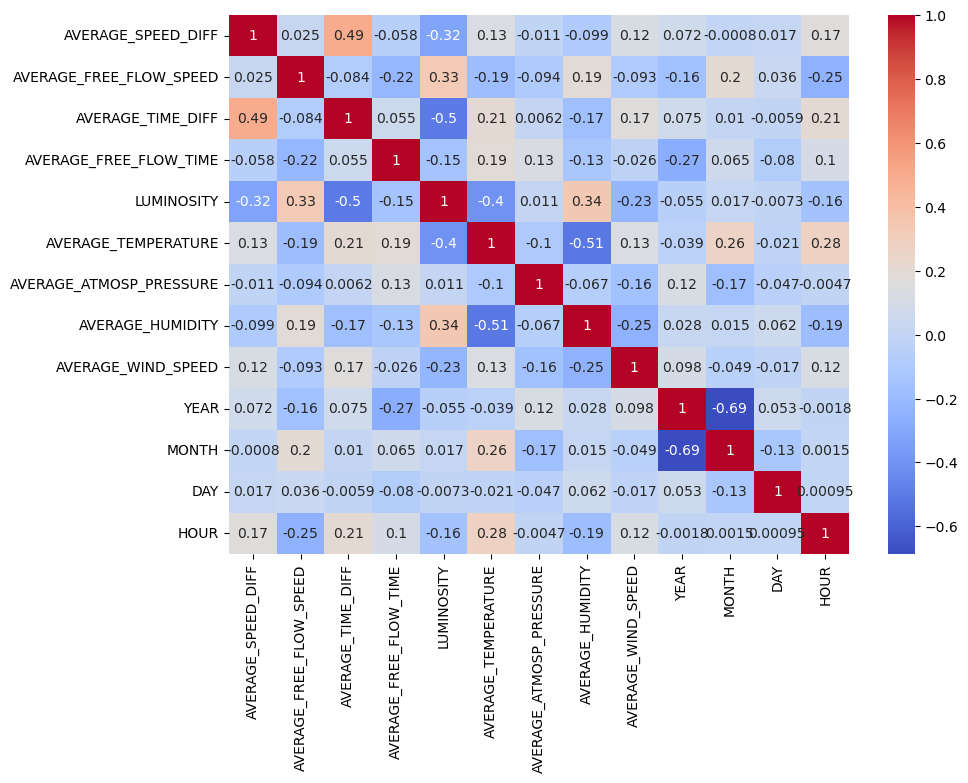

In [97]:
fig = plt.figure(figsize=(10,7))
sns.heatmap(data.corr(method='pearson'), annot=True, cmap='coolwarm')